In [1]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "600"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("HF_ENDPOINT:", os.environ.get("HF_ENDPOINT"))
print("HF_HUB_DISABLE_XET:", os.environ.get("HF_HUB_DISABLE_XET"))

HF_ENDPOINT: https://hf-mirror.com
HF_HUB_DISABLE_XET: 1


In [9]:
MODEL_NAME   = "microsoft/deberta-v2-xxlarge"
DATA_DIR     = "/home/yangdejin/nlpcc/nlpcc_task2/data"
OUTPUT_DIR   = "/home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge"
# Start high on 24GB cards; Trainer will halve it on CUDA OOM.
BATCH_SIZE   = 64
EVAL_BATCH_SIZE = 64
MAX_LENGTH   = 512
LR           = 3e-5
NUM_EPOCHS   = 15
LORA_R       = 32
LORA_ALPHA   = 64
GRADIENT_ACCUMULATION_STEPS = 1
AUTO_FIND_BATCH_SIZE = True
SEED         = 3407
os.makedirs(OUTPUT_DIR, exist_ok=True)
TRAIN_CONTEXT_MODE = "full_context"
EVAL_CONTEXT_MODE = "response_only"

In [3]:
import json
import os
from collections import Counter

VALUE_LABELS = [
    "Self-direction\u2013thought",
    "Self-direction\u2013action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power\u2013dominance",
    "Power\u2013resources",
    "Face",
    "Security\u2013personal",
    "Security\u2013societal",
    "Tradition",
    "Conformity\u2013rules",
    "Conformity\u2013interpersonal",
    "Humility",
    "Benevolence\u2013dependability",
    "Benevolence\u2013caring",
    "Universalism\u2013concern",
    "Universalism\u2013nature",
    "Universalism\u2013tolerance",
]
NUM_CLASSES = len(VALUE_LABELS)
label2id = {v:i for i, v in enumerate(VALUE_LABELS)}
id2label = {i:v for i, v in enumerate(VALUE_LABELS)}
print(f"num of classes:{NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
  for line in f:
    train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("Train class distribution:\n")
for label in VALUE_LABELS:
  print(f"{label} : {counter[label]}")

num of classes:19
Train class distribution:

Self-direction–thought : 119
Self-direction–action : 124
Stimulation : 400
Hedonism : 164
Achievement : 174
Power–dominance : 156
Power–resources : 237
Face : 258
Security–personal : 202
Security–societal : 70
Tradition : 90
Conformity–rules : 385
Conformity–interpersonal : 236
Humility : 100
Benevolence–dependability : 189
Benevolence–caring : 317
Universalism–concern : 160
Universalism–nature : 71
Universalism–tolerance : 68


In [4]:
# Cell 4: 数据加载 + 文本拼接
import json
import torch
import numpy as np
from datasets import Dataset

def build_text(row, context_mode="full_context"):
    response = str(row.get("Consistent Value Response", "")).strip()
    if context_mode == "response_only":
        return "Response: " + response
    if context_mode == "full_context":
        parts = []
        if row.get("Scenario"):
            parts.append("Scenario: " + row.get("Scenario").strip())
        if row.get("Question"):
            parts.append("Question: " + row.get("Question").strip())
        if response:
            parts.append("Response: " + response)
        return " [SEP] ".join(parts)
    
def load_jsonl(path, has_label=True, context_mode = "full_context"):

    texts, labels = [], []
    with open(path) as f:
        for line in f:
            row = json.loads(line)
            texts.append(build_text(row, context_mode))
            if has_label:
                labels.append(label2id[row["Value"]])
    if has_label:
        return Dataset.from_dict({"text": texts, "label": labels})
    return Dataset.from_dict({"text": texts})

train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"), context_mode=EVAL_CONTEXT_MODE)
dev_dataset   = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"), context_mode=EVAL_CONTEXT_MODE)

print(f"Train size : {len(train_dataset)}")
print(f"Dev size   : {len(dev_dataset)}")
print(f"\nTrain sample text:\n{train_dataset[0]['text'][:300]}")
print(f"\nDev sample text:\n{dev_dataset[0]['text'][:300]}")

Train size : 3520
Dev size   : 514

Train sample text:
Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without challenging the manager openly, prioritizing team harmony and respect for hierarchy.

Dev sample text:
Response: I would prioritize maintaining that frequent contact despite my schedule, as I want to ensure my teammate feels valued, included, and that our teamwork remains perfectly smooth.


In [5]:
# Cell 5: 加载模型 + Tokenizer
import torch
from unsloth import FastModel
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding

def print_gpu_memory(stage):
    if not torch.cuda.is_available():
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    peak_allocated = torch.cuda.max_memory_allocated() / 1024**3
    peak_reserved = torch.cuda.max_memory_reserved() / 1024**3
    print(
        f"[{stage}] allocated={allocated:.2f} GB | reserved={reserved:.2f} GB | "
        f"peak_allocated={peak_allocated:.2f} GB | peak_reserved={peak_reserved:.2f} GB"
    )

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    print_gpu_memory("before model load")

model, tokenizer = FastModel.from_pretrained(
    model_name=MODEL_NAME,
    load_in_4bit=False,
    max_seq_length=MAX_LENGTH,
    dtype=torch.bfloat16,
    auto_model=AutoModelForSequenceClassification,
    num_labels=NUM_CLASSES,
    disable_log_stats=True,
    attn_implementation="eager",
)

model.config.id2label = id2label
model.config.label2id = label2id

def tokenize_fn(examples):
    return tokenizer(examples["text"], max_length=MAX_LENGTH, truncation=True)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
dev_dataset   = dev_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print_gpu_memory("after model load")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
[before model load] allocated=0.01 GB | reserved=0.02 GB | peak_allocated=0.01 GB | peak_reserved=0.02 GB
==((====))==  Unsloth 2026.5.4: Fast Deberta_V2 patching. Transformers: 5.10.2. vLLM: 0.19.1.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.595 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


pytorch_model.bin:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/778 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v2-xxlarge
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Total parameters: 1,566,939,667
[after model load] allocated=2.93 GB | reserved=2.93 GB | peak_allocated=2.93 GB | peak_reserved=2.93 GB


In [10]:
model = FastModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    task_type="SEQ_CLS",
)
model.print_trainable_parameters()
print_gpu_memory("after LoRA attach")


/home/yangdejin/miniconda3/envs/nlpcc/lib/python3.12/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/yangdejin/miniconda3/envs/nlpcc/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Unsloth: Allowing gradients for `base_model.model.base_model.model.classifier` since it's in `modules_to_save`.
trainable params: 18,903,571 || all params: 1,585,843,238 || trainable%: 1.1920
[after LoRA attach] allocated=3.21 GB | reserved=3.26 GB | peak_allocated=4.91 GB | peak_reserved=5.11 GB


In [11]:
# Cell 7: 训练（WeightedTrainer 处理类别不均衡）
import evaluate
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from transformers import TrainingArguments, Trainer

# 计算类别权重
train_labels = np.array(train_dataset["label"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Class weights (first 5):", class_weights[:5].round(3))

# 自定义 Trainer，使用加权交叉熵
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=class_weights_tensor)
        return (loss, outputs) if return_outputs else loss

# 评估指标
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

# 训练参数
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    auto_find_batch_size=AUTO_FIND_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=0.1,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_torch",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=SEED,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=20,
    label_names=["labels"],
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print_gpu_memory("before train")
trainer_stats = trainer.train()
print(trainer_stats)
print_gpu_memory("after train")

Class weights (first 5): [1.557 1.494 0.463 1.13  1.065]


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[before train] allocated=3.05 GB | reserved=3.26 GB | peak_allocated=4.91 GB | peak_reserved=5.11 GB


[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,520 | Num Epochs = 15 | Total steps = 825
O^O/ \_/ \    Batch size per device = 64 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (64 x 1 x 1) = 64
 "-____-"     Trainable parameters = 18,903,571 of 1,585,843,238 (1.19% trained)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.266085,1.859129,0.655642,0.631699
2,1.660694,1.230838,0.764591,0.746755
3,1.067178,0.791395,0.832685,0.817740
4,0.733789,0.536427,0.867704,0.849835
5,0.584156,0.433262,0.889105,0.875586
6,0.406842,0.332993,0.900778,0.883830
7,0.338893,0.309236,0.904669,0.895374
8,0.277261,0.256548,0.922179,0.914707
9,0.242331,0.265650,0.924125,0.915743
10,0.230194,0.222968,0.937743,0.929300


[transformers] Unsloth: Restored added_tokens_decoder metadata in /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/checkpoint-330/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/checkpoint-385/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/checkpoint-440/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/checkpoint-495/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/checkpoint-550/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/

TrainOutput(global_step=825, training_loss=0.6006141937140262, metrics={'train_runtime': 1110.8962, 'train_samples_per_second': 47.529, 'train_steps_per_second': 0.743, 'total_flos': 2.4218443358735616e+16, 'train_loss': 0.6006141937140262, 'epoch': 15.0})
[after train] allocated=3.19 GB | reserved=5.09 GB | peak_allocated=4.91 GB | peak_reserved=5.11 GB


Dev Set Evaluation Results
                           precision    recall  f1-score   support

   Self-direction–thought     0.8235    0.8235    0.8235        17
    Self-direction–action     0.8571    1.0000    0.9231        18
              Stimulation     1.0000    0.9655    0.9825        58
                 Hedonism     1.0000    1.0000    1.0000        24
              Achievement     1.0000    0.8462    0.9167        26
          Power–dominance     0.9200    1.0000    0.9583        23
          Power–resources     0.9714    0.9714    0.9714        35
                     Face     0.9211    0.9459    0.9333        37
        Security–personal     0.9643    0.9310    0.9474        29
        Security–societal     0.9091    0.9091    0.9091        11
                Tradition     1.0000    1.0000    1.0000        14
         Conformity–rules     0.9643    0.9818    0.9730        55
 Conformity–interpersonal     0.9355    0.8529    0.8923        34
                 Humility     1.00

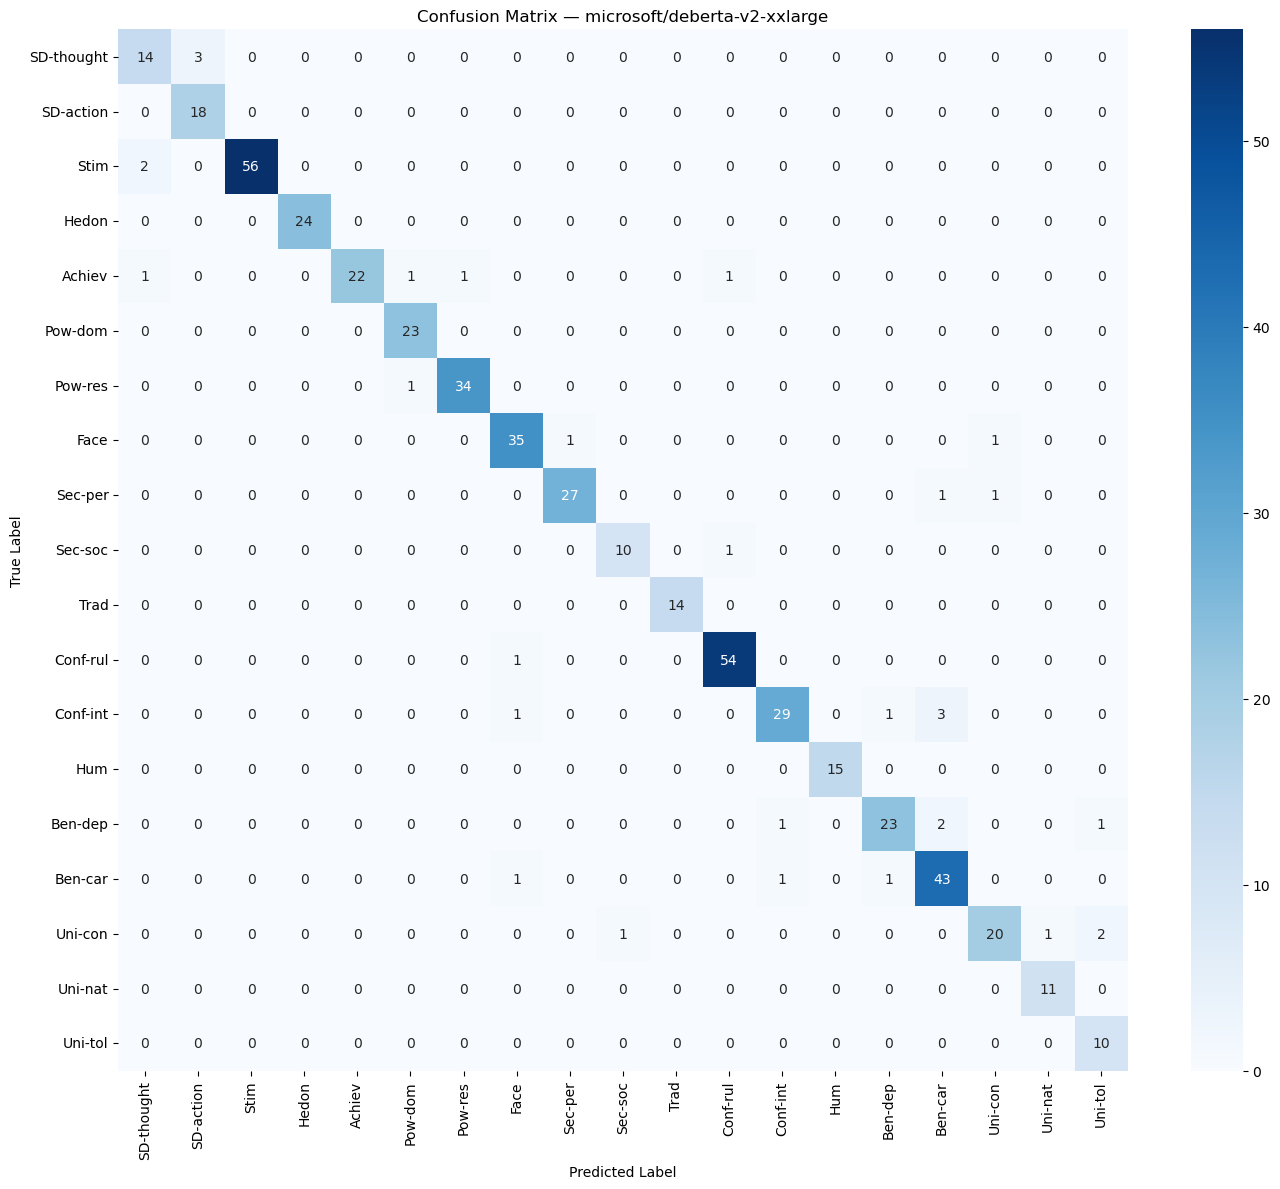

Confusion matrix saved to /home/yangdejin/nlpcc/nlpcc_task2/outputs/encoder/deberta_v2_xxlarge/confusion_matrix.png


In [12]:
# Cell 8: Dev 集综合评估 + 每类 F1 + 混淆矩阵热图
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["label"])

print("=" * 60)
print("Dev Set Evaluation Results")
print("=" * 60)
print(classification_report(
    labels, preds,
    target_names=VALUE_LABELS,
    digits=4
))

# 混淆矩阵热图
cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol"
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_labels, yticklabels=short_labels
)
plt.title(f"Confusion Matrix — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")